                                                UJIAN TENGAH SEMESTER

_____________________________________________
JARINGAN SYARAF TIRUAN_KELAS B
-   JOSEPH SERI APRILLIO DE ORNAY
-   225314118

- Tahapan Pertama Memasukan library yang dibutuhkan ; 
1. Library numpy dan sklearn untuk manipulasi data
2. Library matplotlib untuk visualisasi 

- Tahapan Kedua adalah memisahkan data menjadi data train dan testing setelah normalisasi
- Tahapan Ketiga adalah membangun model mulai dari input data, forward propagation, backpropagation, hingga update parameter
- Tahapan keempat adalah terapkan model pada data dan menampilkan hasil perhitungan costnya
- Tahapan kelima adalah visualisasi sederhana

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data / 255.0   # Normalisasi piksel
Y = mnist.target.astype(int)

In [4]:
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[0]

print ('Shape dari X: ' + str(shape_X))
print ('Shape dari Y: ' + str(shape_Y))
print ('m = %d Jumlah Training' % (m))


Shape dari X: (70000, 784)
Shape dari Y: (70000,)
m = 70000 Jumlah Training


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
y_train_array = np.array(y_train).reshape(-1, 1)
y_test_array = np.array(y_test).reshape(-1, 1)

print("Shape dari y_train_array:", y_train_array.shape)
print("Shape dari y_test_array:", y_test_array.shape)
print("Beberapa sample label y_train_array:", y_train_array[:10].flatten())

Shape dari y_train_array: (56000, 1)
Shape dari y_test_array: (14000, 1)
Beberapa sample label y_train_array: [5 4 8 0 2 6 5 4 8 3]


In [6]:
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train_array)
y_test_oh = encoder.transform(y_test_array)

print ("Shape dari Y Train One Hot Encoder adalah ",y_train_oh.shape,
       "\nShape dari Y Test One Hot Encoder adalah ",y_test_oh.shape)

Shape dari Y Train One Hot Encoder adalah  (56000, 10) 
Shape dari Y Test One Hot Encoder adalah  (14000, 10)


In [7]:
def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2)
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

In [8]:
initialize_parameters(784, 128, 10)

{'W1': array([[-0.00416758, -0.00056267, -0.02136196, ..., -0.00616844,
          0.00321336, -0.00946447],
        [-0.00530139, -0.01259207,  0.01677544, ..., -0.00328425,
         -0.00562311,  0.00117914],
        [ 0.00738638, -0.01587296,  0.001532  , ..., -0.00842856,
          0.01004047,  0.00054583],
        ...,
        [-0.00091732,  0.01252378, -0.00307083, ...,  0.00373258,
         -0.00528649,  0.00531844],
        [ 0.01106253, -0.01071076,  0.00123177, ..., -0.0005062 ,
          0.00239901, -0.00843219],
        [ 0.00465213, -0.00260906,  0.01624186, ..., -0.00480135,
         -0.00563801,  0.00388592]], shape=(128, 784)),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
       

In [9]:
# 4. Forward Propagation
def relu(nilai_z):
    return np.maximum(0, nilai_z)

def softmax(nilai_Z):
    expZ = np.exp(nilai_Z - np.max(nilai_Z, axis=0, keepdims=True))
    hasilexpZ = expZ / np.sum(expZ, axis=0, keepdims=True)
    return hasilexpZ

def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache


In [10]:
def compute_cost(A2, Y):
    m = Y.shape[1]                  #epsilon agar mencegah hasil log tidak terdefinisi
    logprobs = np.log(A2 + 1e-8)  #logprobs agar hasil dari prediksi benar true atau false
    cost = -np.sum(Y * logprobs) / m 
    return cost

In [11]:
# 6. Backward Propagation
def relu_derivative(Z):
    return (Z > 0).astype(float)

def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]
    
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    
    A1 = cache["A1"]
    A2 = cache["A2"]
    Z1 = cache["Z1"]
    
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads


In [12]:
def update_parameters(parameters, grads, learning_rate=0.5):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    return parameters

In [13]:
def model(X, Y, n_h, iterasi=1000, learning_rate=0.5, print_cost=False):
    np.random.seed(3)
    n_x = X.shape[0]
    n_y = Y.shape[0]
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    costs = []
    
    for i in range(iterasi):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if print_cost and i % 100 == 0:
            print(f"Cost after iteration {i}: {cost}")
            costs.append(cost)
    
    return parameters, costs

In [14]:
def predict(X, parameters):
    A2, _ = forward_propagation(X, parameters)
    predictions = np.argmax(A2, axis=0)
    return predictions

In [15]:
X_train_T = np.array(X_train).T  # (784, jumlah data)
X_test_T = np.array(X_test).T
y_train_T = y_train_oh.T  # (10, jumlah data)
y_test_T = y_test_oh.T

# Train model
parameters, costs = model(X_train_T, y_train_T, n_h=128, iterasi=1000, learning_rate=0.5, print_cost=True)

# Prediksi
y_pred_train = predict(X_train_T, parameters)
y_pred_test = predict(X_test_T, parameters)

# bandingkan prediksi dengan label asli
train_accuracy = np.mean(y_pred_train == np.array(y_train)) * 100
test_accuracy = np.mean(y_pred_test == np.array(y_test)) * 100

print(f"Train Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Cost after iteration 0: 2.303260764219594
Cost after iteration 100: 0.33015403609043
Cost after iteration 200: 0.2483334367924827
Cost after iteration 300: 0.20373010157008944
Cost after iteration 400: 0.17357550028457344
Cost after iteration 500: 0.1511326266543131
Cost after iteration 600: 0.133503122961784
Cost after iteration 700: 0.11934481276448725
Cost after iteration 800: 0.10779631116464812
Cost after iteration 900: 0.09813559042929493
Train Accuracy: 97.52%
Test Accuracy: 96.53%


In [16]:
def hasil_klasifikasi(y_true, y_pred):
    print("\nHasil Klasifikasi:")
    print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

In [17]:
def tampilkan_hasil_prediksi(X_data, y_true, y_pred, jumlah_sampel=5):
    # ubah semua data dalam format NumPy array
    X = np.array(X_data)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    if X.shape[0] == 784:
        X = X.T  # jaga jaga ketika dimensinya tidak sesuai
    
    print("Hasil Prediksi:")
    
    # Ambil indeks sampel acak
    indeks_sampel = np.random.choice(len(y_true), jumlah_sampel, replace=False)
    
    # Buat plot dengan 1 baris, jumlah sampel kolom
    plt.figure(figsize=(2*jumlah_sampel, 4))
    
    for i, idx in enumerate(indeks_sampel):
        # Ambil gambar
        gambar = X[idx].reshape(28, 28)
        prediksi = y_pred[idx]
        nilai_benar = y_true[idx]
        
        # Cek apakah prediksi benar
        benar = prediksi == nilai_benar
        
        # Buat subplot
        plt.subplot(1, jumlah_sampel, i+1)
        plt.imshow(gambar, cmap='gray')
        
        # Judul hijau jika true pred atau merah jika false pred
        warna = 'green' if benar else 'red'
        judul = f"Prediksi: {prediksi}\nAsli: {nilai_benar}"
        plt.title(judul, color=warna)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


Hasil Prediksi:


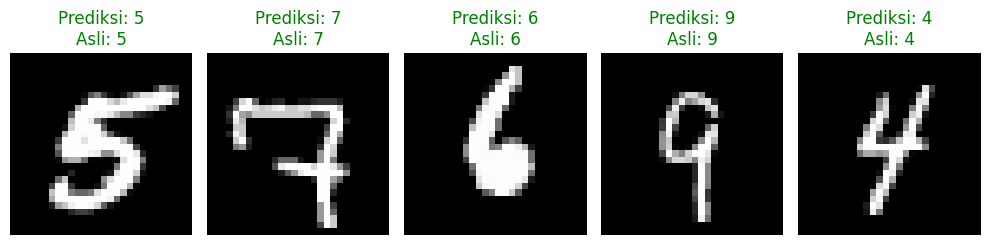


Hasil Klasifikasi:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1343
           1       0.97      0.98      0.98      1600
           2       0.97      0.96      0.96      1380
           3       0.96      0.96      0.96      1433
           4       0.96      0.96      0.96      1295
           5       0.96      0.96      0.96      1273
           6       0.97      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.95      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.96      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [18]:
tampilkan_hasil_prediksi(X_test, y_test, y_pred_test, jumlah_sampel=5)
hasil_klasifikasi(y_test, y_pred_test)

- Sebagai pelengkap dari presentasi saya menambahkan confusion matrix yang berguna untuk mengukur performa model melakukan klasifikasi multiclass. Pada kasus saya, klasifikasi multiclass yang memprediski gambar angka yang muncul yang terdapat 10 kelas. Sehingga satu gambar akan masuk pada sebuah kelas.  

- Confusion matrix ini penting dikarenakan dapat melakukan pengukuran accuracy, precission, dan recall. 

- Accuracy berguna untuk menggambarkan seberapa akurat model dapat melakukan klasifikasi dengan benar. Hal ini diukur dari prediksi benar terhadap keseluruhan data. 

- Precission berguna untuk menggambarkan tingkat keakuratan antara data yang diminta dengan hasil prediksi oleh model. Hal ini diukur dari rasio benar positif dengan keseluruhan hasil yang diprediksi positif. 

- Recall berguna untuk menggambarkan keberhasilan model dalam menemukan informasi yang benar. Hal ini diukur dari rasio prediksi benar positif dibandingkan keseluruhan data benar positif. 

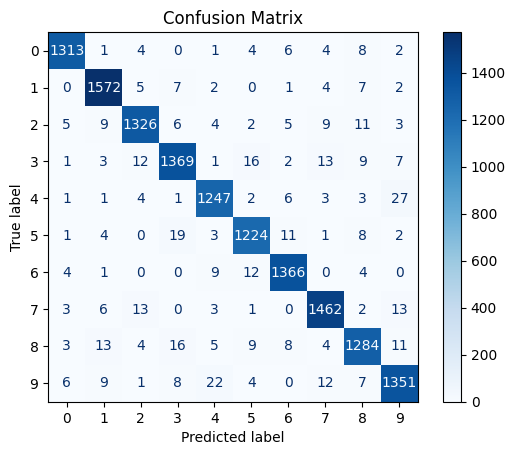

In [19]:
disp = metrics.ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=encoder.categories_[0])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Melihat dari hasil dari confusion matrix, dapat disimpulkan bahwa model mampu melakukan prediksi sesuai dengan yang diinginkan dengan baik. 
Hal ini dilihat dari keseluruhan label kelas yang  mana kelas dengan sebagai berikut: 
1. label kelas 0 mampu diprediksi dengan benar sebanyak 1313 kali.
2. label kelas 1 mampu diprediksi dengan benar sebanyak 1572 kali.
3. label kelas 2 mampu diprediksi dengan benar sebanyak 1326 kali.
4. label kelas 3 mampu diprediksi dengan benar sebanyak 1369 kali.
5. label kelas 4 mampu diprediksi dengan benar sebanyak 1247 kali.
6. label kelas 5 mampu diprediksi dengan benar sebanyak 1224 kali.
7. label kelas 6 mampu diprediksi dengan benar sebanyak 1366 kali.
8. label kelas 7 mampu diprediksi dengan benar sebanyak 1462 kali. 
9. label kelas 8 mampu diprediksi dengan benar sebanyak 1284 kali.
10. label kelas 9 mampu diprediksi dengan benar sebanyak 1351 kali.

Disamping berbagai prediksi yang benar tersebut adanya prediksi yang salah dari setiap kelas. Sehingga jika dibandingkan perbandingannya dapat dikatakan sangat jauh. Sehingga melihat dari hal itu, model sudah dapat dikatakan mampu melakukan klasifikasi dengan baik. 